In [ ]:
# ============================================================
# DATA6000 - LSTM Forecast and Scenario Analysis
# Argentina Gas Export Feasibility
# ============================================================

# 1. Install / import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Upload Excel file
uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]

# Load Excel file
df = pd.read_excel(file_name)

# Check columns
print(df.head())
print(df.columns)

Saving DATA6000 WEEK 5 power bi.xlsx to DATA6000 WEEK 5 power bi (1).xlsx
        Date  Production     Demand  P-C (BCF)  X (BCF)  I (BCF)  E-I (BCF)  \
0 1993-01-01   70.358453  58.403239  11.955214      NaN      NaN        NaN   
1 1993-02-01   65.685188  52.774570  12.910618      NaN      NaN        NaN   
2 1993-03-01   72.790423  62.195367  10.595057      NaN      NaN        NaN   
3 1993-04-01   75.389141  63.853710  11.535432      NaN      NaN        NaN   
4 1993-05-01   80.839339  70.422844  10.416494      NaN      NaN        NaN   

   GDP per capita USD  Population  GDP USD  C RESIDENTIAL  C COMERCIAL  \
0                 NaN         NaN      NaN       6.428194     1.334931   
1                 NaN         NaN      NaN       5.811705     1.171989   
2                 NaN         NaN      NaN       7.658346     1.828277   
3                 NaN         NaN      NaN       9.904890     1.952232   
4                 NaN         NaN      NaN      20.654720     3.132873   

   C O

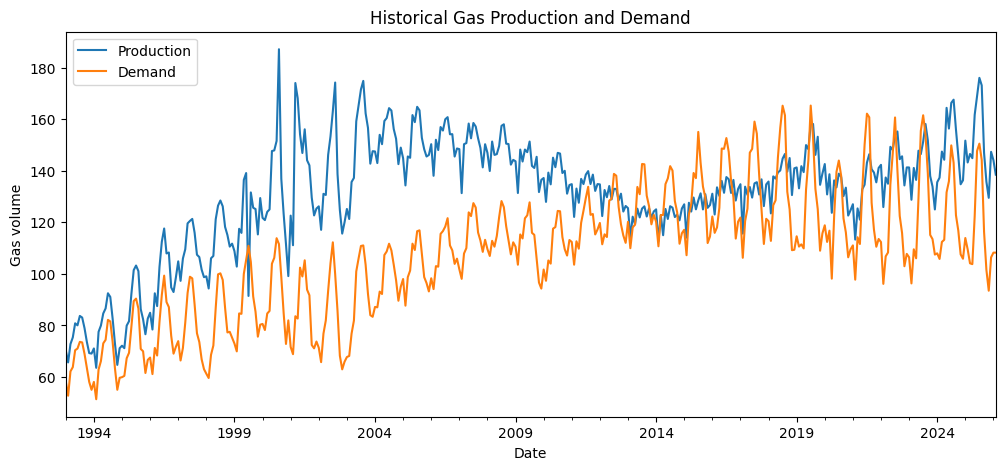

In [ ]:
# ============================================================
# 2. Basic cleaning
# ============================================================

# Adjust these column names if needed
DATE_COL = "Date"
PRODUCTION_COL = "Production"
DEMAND_COL = "Demand"

# Convert date column
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

# Sort by date
df = df.sort_values(DATE_COL)

# Set date as index
df = df.set_index(DATE_COL)

# Keep monthly frequency
df = df.asfreq("MS")

# Interpolate missing values
df[PRODUCTION_COL] = df[PRODUCTION_COL].interpolate()
df[DEMAND_COL] = df[DEMAND_COL].interpolate()

# Check cleaned data
df[[PRODUCTION_COL, DEMAND_COL]].plot(figsize=(12, 5))
plt.title("Historical Gas Production and Demand")
plt.xlabel("Date")
plt.ylabel("Gas volume")
plt.show()

In [ ]:
# ============================================================
# 3. Helper functions for LSTM
# ============================================================

def create_sequences(data, lookback=12):
    """
    Converts a time series into supervised learning sequences.
    Example: previous 12 months predict next month.
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i-lookback:i])
        y.append(data[i])
    return np.array(X), np.array(y)


def build_lstm_model(lookback):
    """
    Builds a simple LSTM model for monthly time-series forecasting.
    """
    model = Sequential()
    model.add(LSTM(64, activation="tanh", return_sequences=True, input_shape=(lookback, 1)))
    model.add(Dropout(0.2))
    model.add(LSTM(32, activation="tanh"))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(
        optimizer="adam",
        loss="mse"
    )

    return model


def mape(y_true, y_pred):
    """
    Mean Absolute Percentage Error.
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def train_lstm_forecast(series, forecast_months=60, lookback=12, epochs=150, batch_size=16):
    """
    Trains an LSTM model and forecasts future values.
    Returns model, scaler, fitted values, future forecast, and metrics.
    """

    # Convert to numpy
    values = series.values.reshape(-1, 1)

    # Scale data
    scaler = MinMaxScaler()
    scaled_values = scaler.fit_transform(values)

    # Create sequences
    X, y = create_sequences(scaled_values, lookback)

    # Train/test split for model checking
    split = int(len(X) * 0.8)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    # Reshape for LSTM: samples, timesteps, features
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

    # Build model
    model = build_lstm_model(lookback)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    # Train
    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stop]
    )

    # Test prediction
    y_test_pred_scaled = model.predict(X_test, verbose=0)

    # Inverse transform
    y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
    y_test_pred = scaler.inverse_transform(y_test_pred_scaled).flatten()

    # Metrics
    mae = mean_absolute_error(y_test_actual, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test_actual, y_test_pred))
    mape_value = mape(y_test_actual, y_test_pred)

    metrics = {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape_value
    }

    # Forecast future months recursively
    last_sequence = scaled_values[-lookback:].reshape(1, lookback, 1)
    future_scaled = []

    for _ in range(forecast_months):
        next_pred = model.predict(last_sequence, verbose=0)[0][0]
        future_scaled.append(next_pred)

        # update sequence
        last_sequence = np.append(
            last_sequence[:, 1:, :],
            [[[next_pred]]],
            axis=1
        )

    future_forecast = scaler.inverse_transform(
        np.array(future_scaled).reshape(-1, 1)
    ).flatten()

    return model, scaler, future_forecast, metrics, history

In [ ]:
# ============================================================
# 4. Train LSTM models
# ============================================================

LOOKBACK = 12
FORECAST_MONTHS = 60   # 5 years monthly forecast

demand_model, demand_scaler, demand_forecast, demand_metrics, demand_history = train_lstm_forecast(
    df[DEMAND_COL],
    forecast_months=FORECAST_MONTHS,
    lookback=LOOKBACK
)

production_model, production_scaler, production_forecast, production_metrics, production_history = train_lstm_forecast(
    df[PRODUCTION_COL],
    forecast_months=FORECAST_MONTHS,
    lookback=LOOKBACK
)

print("Demand LSTM Metrics:", demand_metrics)
print("Production LSTM Metrics:", production_metrics)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Demand LSTM Metrics: {'MAE': 7.612930841045822, 'RMSE': np.float64(9.104388448392035), 'MAPE': np.float64(6.351031436705494)}
Production LSTM Metrics: {'MAE': 6.692642265170255, 'RMSE': np.float64(8.157701158306855), 'MAPE': np.float64(4.810443616831018)}


In [ ]:
# ============================================================
# 5. Build forecast dataframe
# ============================================================

last_date = df.index[-1]

future_dates = pd.date_range(
    start=last_date + pd.DateOffset(months=1),
    periods=FORECAST_MONTHS,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "LSTM_Demand": demand_forecast,
    "LSTM_Production": production_forecast
})

forecast_df = forecast_df.set_index("Date")

forecast_df.head()

,LSTM_Demand,LSTM_Production
Date,,
2026-03-01,106.994354,150.714432
2026-04-01,117.977623,157.375000
2026-05-01,133.072006,163.666214
2026-06-01,144.316498,165.969009
2026-07-01,143.294113,164.184891


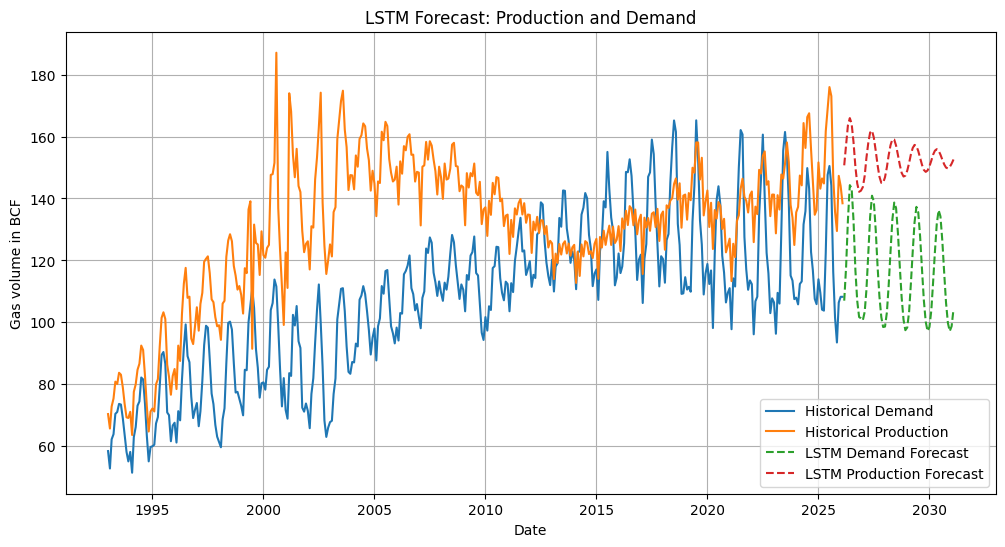

In [ ]:
# ============================================================
# 6. Plot historical + LSTM forecast
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(df.index, df[DEMAND_COL], label="Historical Demand")
plt.plot(df.index, df[PRODUCTION_COL], label="Historical Production")

plt.plot(forecast_df.index, forecast_df["LSTM_Demand"], linestyle="--", label="LSTM Demand Forecast")
plt.plot(forecast_df.index, forecast_df["LSTM_Production"], linestyle="--", label="LSTM Production Forecast")

plt.title("LSTM Forecast: Production and Demand")
plt.xlabel("Date")
plt.ylabel("Gas volume in BCF")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ============================================================
# 7. Convert monthly BCF to Bcf/d
# ============================================================

# Set this to True if your data is monthly total BCF.
# Set to False if your data is already Bcf/d.
CONVERT_MONTHLY_TO_BCFD = True

if CONVERT_MONTHLY_TO_BCFD:
    days_in_month = forecast_df.index.days_in_month

    forecast_df["Baseline_Demand_Bcfd"] = forecast_df["LSTM_Demand"] / days_in_month
    forecast_df["Baseline_Production_Bcfd"] = forecast_df["LSTM_Production"] / days_in_month
else:
    forecast_df["Baseline_Demand_Bcfd"] = forecast_df["LSTM_Demand"]
    forecast_df["Baseline_Production_Bcfd"] = forecast_df["LSTM_Production"]

forecast_df.tail()

,LSTM_Demand,LSTM_Production,Baseline_Demand_Bcfd,Baseline_Production_Bcfd
Date,,,,
2030-10-01,106.340179,149.989349,3.430328,4.838366
2030-11-01,99.764687,149.701584,3.325490,4.990053
2030-12-01,97.133400,150.175613,3.133335,4.844375
2031-01-01,98.717812,151.245316,3.184446,4.878881
2031-02-01,104.246796,152.601425,3.723100,5.450051


In [ ]:
# ============================================================
# 8. LNG demand layer
# Same assumptions as SARIMA scenario model
# ============================================================

forecast_df["LNG_Demand_Bcfd"] = 0.0

for date in forecast_df.index:
    year = date.year

    if year < 2027:
        lng = 0.0
    elif year < 2029:
        lng = 0.7
    elif year < 2031:
        lng = 1.8
    else:
        lng = 3.5

    forecast_df.loc[date, "LNG_Demand_Bcfd"] = lng

forecast_df["Total_Demand_With_LNG_Bcfd"] = (
    forecast_df["Baseline_Demand_Bcfd"] + forecast_df["LNG_Demand_Bcfd"]
)

In [ ]:
# ============================================================
# 9. Production scenario pathways
# Same scenario construction as SARIMA model:
# linear trend to target + LSTM seasonal pattern
# ============================================================

base_production = forecast_df["Baseline_Production_Bcfd"].to_numpy()
n = len(base_production)
start_value = base_production[0]

# Linear growth trend to targets
trend_6 = np.array([
    start_value + (6.0 - start_value) * (i / (n - 1))
    for i in range(n)
])

trend_8 = np.array([
    start_value + (8.0 - start_value) * (i / (n - 1))
    for i in range(n)
])

# Keep LSTM seasonal/monthly pattern
seasonality = base_production - np.mean(base_production)

forecast_df["Production_Rystad_6_Bcfd"] = trend_6 + seasonality
forecast_df["Production_YPF_8_Bcfd"] = trend_8 + seasonality

In [ ]:
# ============================================================
# 10. Transport capacity assumptions
# Same assumptions as SARIMA scenario model
# ============================================================

forecast_df["Transport_Capacity_Bcfd"] = 0.0

for date in forecast_df.index:
    year = date.year

    if year <= 2026:
        capacity = 4.8
    elif year <= 2027:
        capacity = 5.3
    elif year <= 2028:
        capacity = 6.1
    else:
        capacity = 7.9

    forecast_df.loc[date, "Transport_Capacity_Bcfd"] = capacity

In [ ]:
# ============================================================
# 11. Supply gap calculation
# ============================================================

forecast_df["Gap_Rystad_Bcfd"] = (
    forecast_df["Production_Rystad_6_Bcfd"] - forecast_df["Total_Demand_With_LNG_Bcfd"]
)

forecast_df["Gap_YPF_Bcfd"] = (
    forecast_df["Production_YPF_8_Bcfd"] - forecast_df["Total_Demand_With_LNG_Bcfd"]
)

forecast_df.tail(12)

,LSTM_Demand,LSTM_Production,Baseline_Demand_Bcfd,Baseline_Production_Bcfd,LNG_Demand_Bcfd,Total_Demand_With_LNG_Bcfd,Production_Rystad_6_Bcfd,Production_YPF_8_Bcfd,Transport_Capacity_Bcfd,Gap_Rystad_Bcfd,Gap_YPF_Bcfd
Date,,,,,,,,,,,
2030-03-01,112.542336,154.090042,3.630398,4.970647,1.8,5.430398,5.735378,7.362497,7.9,0.304981,1.932099
2030-04-01,122.716301,155.442917,4.090543,5.181431,1.8,5.890543,5.965455,7.626472,7.9,0.074911,1.735928
2030-05-01,131.681076,155.928055,4.247777,5.029937,1.8,6.047777,5.833254,7.528169,7.9,-0.214523,1.480392
2030-06-01,136.243408,155.443848,4.541447,5.181462,1.8,6.341447,6.004070,7.732884,7.9,-0.337377,1.391437
2030-07-01,134.234802,154.180634,4.330155,4.973569,1.8,6.130155,5.815470,7.578182,7.9,-0.314685,1.448027
2030-08-01,126.339500,152.544846,4.075468,4.920801,1.8,5.875468,5.781995,7.578605,7.9,-0.093473,1.703137
2030-09-01,115.890724,151.013870,3.863024,5.033796,1.8,5.663024,5.914281,7.744790,7.9,0.251257,2.081766
2030-10-01,106.340179,149.989349,3.430328,4.838366,1.8,5.230328,5.738144,7.602551,7.9,0.507816,2.372222
2030-11-01,99.764687,149.701584,3.325490,4.990053,1.8,5.125490,5.909123,7.807428,7.9,0.783633,2.681938


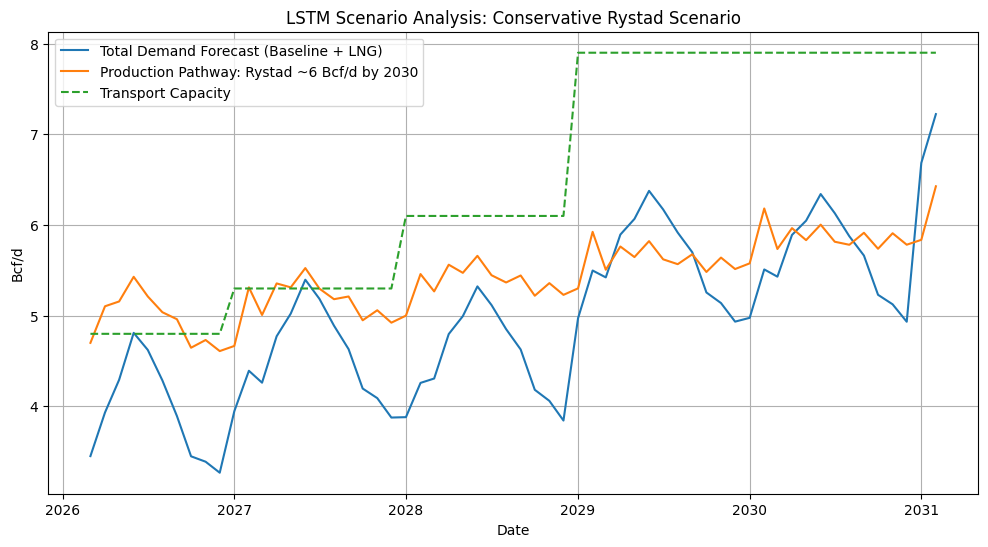

In [ ]:
# ============================================================
# 12. Plot Conservative Rystad Scenario
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    forecast_df.index,
    forecast_df["Total_Demand_With_LNG_Bcfd"],
    label="Total Demand Forecast (Baseline + LNG)"
)

plt.plot(
    forecast_df.index,
    forecast_df["Production_Rystad_6_Bcfd"],
    label="Production Pathway: Rystad ~6 Bcf/d by 2030"
)

plt.plot(
    forecast_df.index,
    forecast_df["Transport_Capacity_Bcfd"],
    linestyle="--",
    label="Transport Capacity"
)



plt.title("LSTM Scenario Analysis: Conservative Rystad Scenario")
plt.xlabel("Date")
plt.ylabel("Bcf/d")
plt.legend()
plt.grid(True)
plt.show()

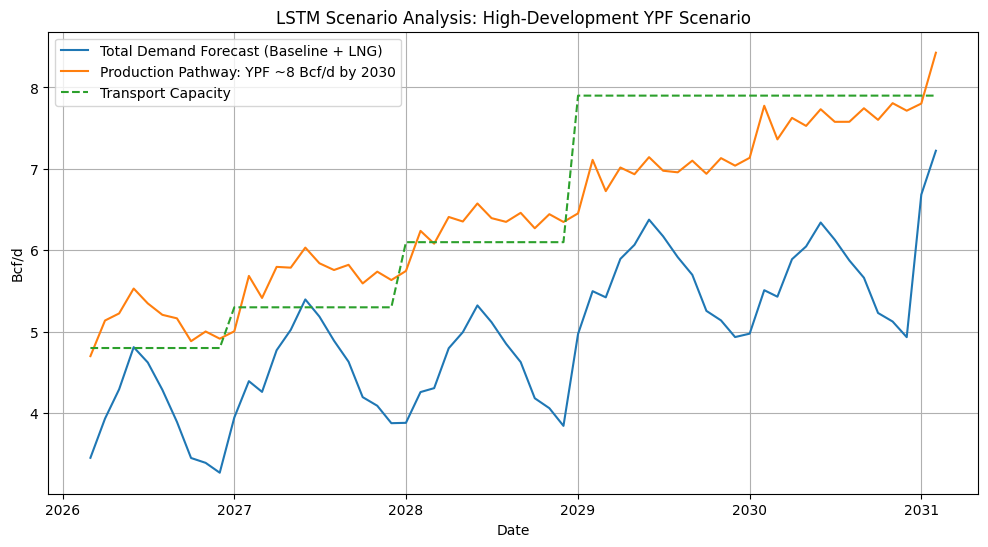

In [ ]:
# ============================================================
# 13. Plot High-Development YPF Scenario
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    forecast_df.index,
    forecast_df["Total_Demand_With_LNG_Bcfd"],
    label="Total Demand Forecast (Baseline + LNG)"
)

plt.plot(
    forecast_df.index,
    forecast_df["Production_YPF_8_Bcfd"],
    label="Production Pathway: YPF ~8 Bcf/d by 2030"
)

plt.plot(
    forecast_df.index,
    forecast_df["Transport_Capacity_Bcfd"],
    linestyle="--",
    label="Transport Capacity"
)



plt.title("LSTM Scenario Analysis: High-Development YPF Scenario")
plt.xlabel("Date")
plt.ylabel("Bcf/d")
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
# ============================================================
# 14. Summary table
# ============================================================

summary = pd.DataFrame({
    "Model": ["LSTM Demand", "LSTM Production"],
    "MAE": [demand_metrics["MAE"], production_metrics["MAE"]],
    "RMSE": [demand_metrics["RMSE"], production_metrics["RMSE"]],
    "MAPE": [demand_metrics["MAPE"], production_metrics["MAPE"]]
})

summary

,Model,MAE,RMSE,MAPE
0,LSTM Demand,7.612931,9.104388,6.351031
1,LSTM Production,6.692642,8.157701,4.810444


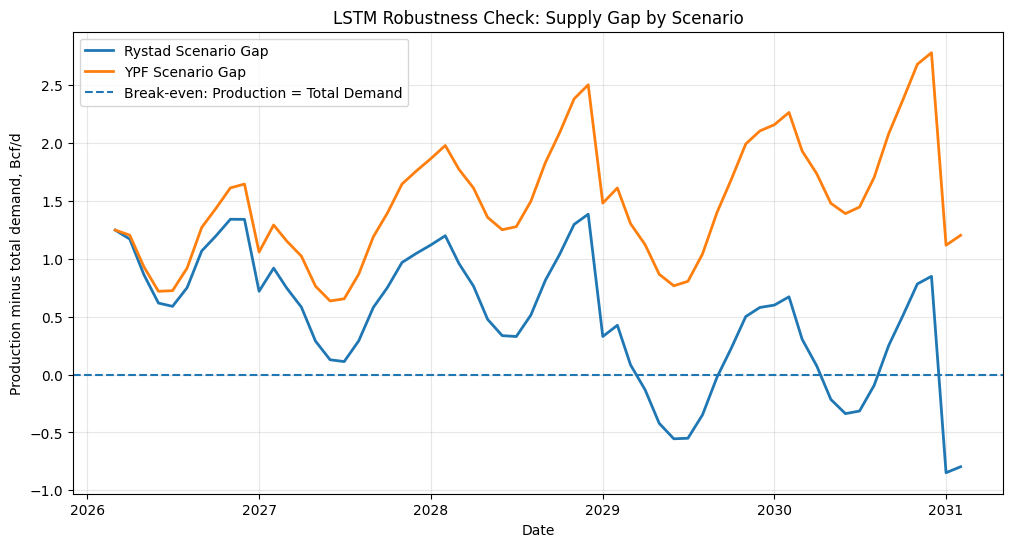

In [ ]:
# ============================================================
# 15. Supply Gap Comparison Chart
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    forecast_df.index,
    forecast_df["Gap_Rystad_Bcfd"],
    label="Rystad Scenario Gap",
    linewidth=2
)

plt.plot(
    forecast_df.index,
    forecast_df["Gap_YPF_Bcfd"],
    label="YPF Scenario Gap",
    linewidth=2
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1.5,
    label="Break-even: Production = Total Demand"
)

plt.title("LSTM Robustness Check: Supply Gap by Scenario")
plt.xlabel("Date")
plt.ylabel("Production minus total demand, Bcf/d")
plt.legend()
plt.grid(alpha=0.3)
plt.show()